### Ball and Beam

In [27]:
from IPython.display import Image
Image(url="Model_pic.png", width=500, height=300)

System Description
 - **Ball position**: \( $l$ \) (distance from a fixed point), degree of freedom.
 - **Control parameter**: Beam angle \( $\varphi$ \).
 - **Goal**: Determine how \( $l$ \) depends on \( $\varphi$ \) and stop the ball at a desired position.
 
1. Degrees of Freedom
 The ball moves along the beam, so the only generalized coordinate is \( $l$ \).  
 The beam angle \( $\varphi$ \) is the control input (not a degree of freedom).
 
2. Equation of motion (Lagrange)
 
 The correct Lagrange equation for this system is:
 
 \
 $\ddot{l} - l\,\dot{\varphi}^2 = -g \sin\varphi$
 
 
 (Derived from kinetic energy \( KE = $\frac12 m\dot l^2$ + $\frac12 m l^2\dot\varphi^2$ \) and potential \( PE = -mg $l\sin\varphi$ \)).


 

In [30]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define symbols
t = sp.symbols('t')
m, g = sp.symbols('m g')
l = sp.Function('l')(t)
phi = sp.Function('phi')(t)

l_dot = sp.diff(l, t)
phi_dot = sp.diff(phi, t)

# Kinetic and potential energy
T = (1/2) * m * l_dot**2 + (1/2) * m * l**2 * phi_dot**2
V = -m * g * l * sp.sin(phi)   # Sign may need checking

L = T - V

# Lagrange equation for l
# d/dt (∂L/∂l_dot) - ∂L/∂l = 0
dL_dl_dot = sp.diff(L, l_dot)
dL_dl = sp.diff(L, l)

lagrange_eq = sp.diff(dL_dl_dot, t) - dL_dl
lagrange_eq = sp.simplify(lagrange_eq)

print("Lagrange equation for l:")
#sp.pprint(lagrange_eq)

L_=sp.Eq(sp.diff(l, t, t) - l * phi_dot**2, -g * sp.sin(phi))
L_

Lagrange equation for l:


Eq(-l(t)*Derivative(phi(t), t)**2 + Derivative(l(t), (t, 2)), -g*sin(phi(t)))

3. Static Characteristic
 
 For static equilibrium, set all time derivatives to zero: \( $\dot{l}=0, \ddot{l}=0, \dot{\varphi}=0$ \). 

 Then the ODE reduces to:

 \
 0 = -m g $\sin\varphi$

 **Plot of the static equilibrium**
 
 The plot below shows the allowed equilibrium points: the entire vertical line at \( $\varphi = 0$ \) (for $\ n=0$ \).

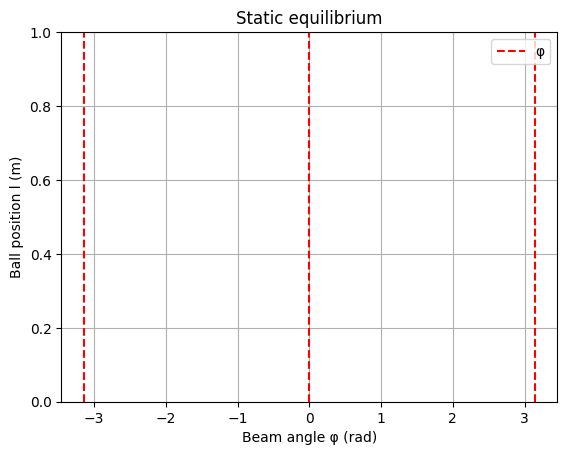

In [31]:
# %%
phi_eq = np.array([-np.pi, 0, np.pi])   # in radians
l_vals = np.linspace(-0.5, 0.5, 100)    # arbitrary range of l
g = 9.81
for phi in phi_eq:
    plt.axvline(phi, color='r', linestyle='--', label=f'φ' if phi==0 else None)

plt.xlabel('Beam angle φ (rad)')
plt.ylabel('Ball position l (m)')
plt.title('Static equilibrium')
plt.legend()
plt.grid(True)
plt.show()




The ball position \( $l$ \) does **not** appear in the equilibrium condition it can be **any** value when \( $\varphi = 0$ \).
 The ball can rest at any $l$ when φ = nπ 
 Therefore there is no unique static characteristic \( $l(\varphi)$ \) instead the ball can rest at any \( l \) only if the beam is horizontal.